In [1]:
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

In [2]:
titanic_data = sns.load_dataset("titanic")
titanic_data.head()
titanic_data.describe
titanic_data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [3]:
features = ["pclass","age","sex","fare","embarked"]
target = ["survived"]

In [4]:
## Handle missing values 
imp_median = SimpleImputer(strategy="median")
imp_mode = SimpleImputer(strategy="most_frequent")
titanic_data["age"]= imp_median.fit_transform(titanic_data[["age"]]).ravel() ## imputer retyrns 2d df ravel converts it into (n,1)=>(n)
titanic_data["embarked"]= imp_mode.fit_transform(titanic_data[["embarked"]]).ravel()

In [5]:
## Encode our features
titanic_data.head()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

titanic_data["sex"] = le.fit_transform(titanic_data["sex"])
titanic_data["embarked"] = le.fit_transform(titanic_data["embarked"])

In [6]:
X = titanic_data[features]
y = titanic_data["survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [7]:
X_train , X_test , y_train, y_test = train_test_split(X , y , test_size=0.2, random_state=42)

In [8]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
print("Training Accuracy:",accuracy_score(y_train,y_pred_train))
print("Testing Accuracy:",accuracy_score(y_test,y_pred_test))

Training Accuracy: 0.9775280898876404
Testing Accuracy: 0.7653631284916201


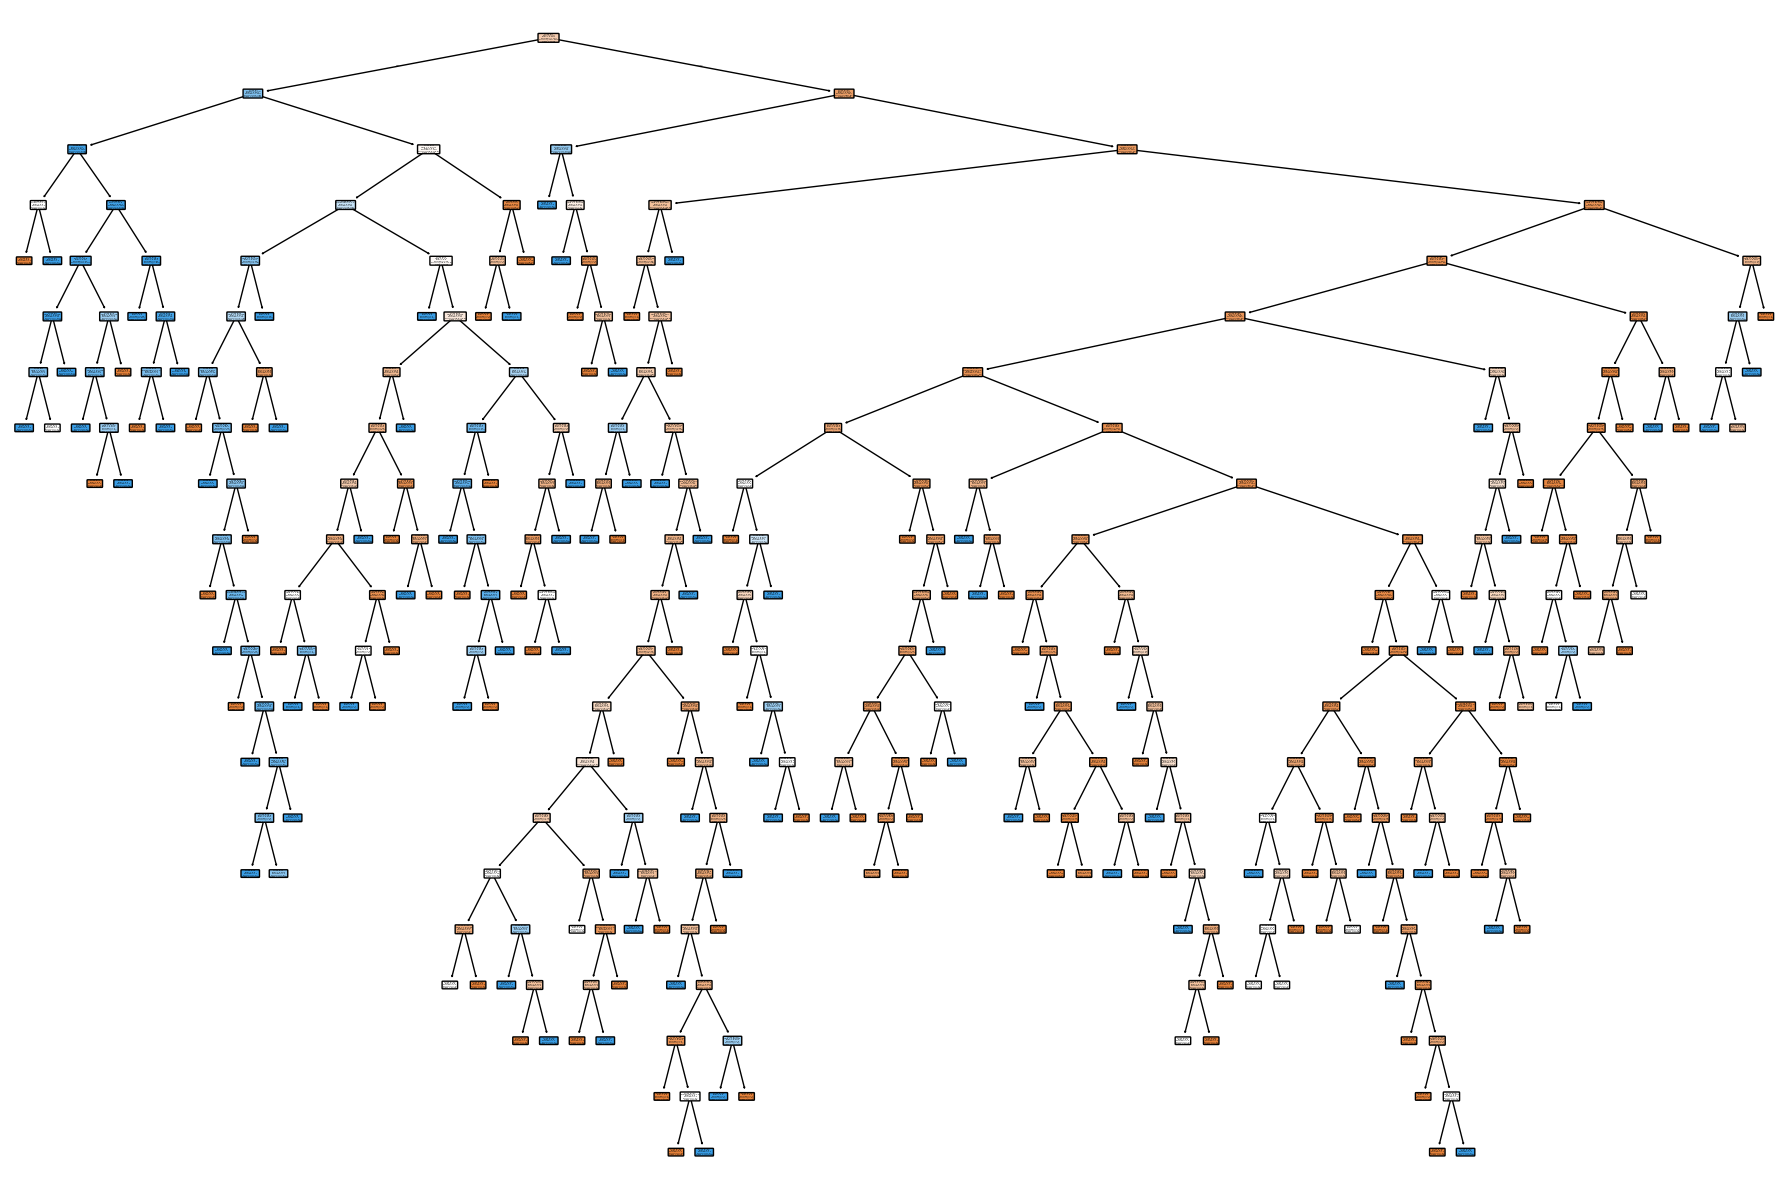

In [10]:
## plottining decision Tree 
from sklearn.tree import plot_tree
plt.figure(figsize=(18,12))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    node_ids = True,
    rounded = True,
)

plt.tight_layout()
plt.show()

## Ensemble Bagging Method with Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

In [12]:
rf = RandomForestClassifier(
    n_estimators=501,
    oob_score=True
)

rf.fit(X_train , y_train)

,n_estimators,501
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [13]:
y_pred = rf.predict(X_test)
print("oob score",rf.oob_score_)
print("Testing Accuracy:",accuracy_score(y_test,y_pred))

oob score 0.797752808988764
Testing Accuracy: 0.7932960893854749


## Bagging classifier

In [14]:
from sklearn.ensemble import BaggingClassifier

In [15]:
bagging_classifier = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=201
)
bagging_classifier.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,201
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [16]:
y_pred = bagging_classifier.predict(X_test)

print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100, "%")

Testing Accuracy: 80.44692737430168 %


## Bagging regressor

In [17]:
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LogisticRegression
bagging = BaggingRegressor(
    estimator=LogisticRegression(),
    n_estimators=201
)
bagging.fit(X_train,y_train)

,estimator,LogisticRegression()
,n_estimators,201
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [18]:
y_pred = bagging_classifier.predict(X_test)
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100, "%")

Testing Accuracy: 80.44692737430168 %


## Bagging Regressor with LinearSVR, KNN Regressor

In [19]:
from sklearn.preprocessing import StandardScaler
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.svm import LinearSVR

bagging_svr = BaggingRegressor(
    estimator=LinearSVR(max_iter=50000000),
    n_estimators=201,
    random_state=42
)

bagging_svr.fit(X_train, y_train)

In [21]:
y_pred = model.predict(X_test)
print("Testing Accuracy:",accuracy_score(y_test,y_pred)*100, "%")

Testing Accuracy: 76.53631284916202 %
